In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
            )
        
    def forward(self, x):
        return self.net(x)

In [3]:
def initial_condition(x, y):
    return torch.sin(torch.pi * x) * torch.sin(torch.pi * y)

def boundary_condition(x, y, t, custom_value):
    return torch.full_like(x, custom_value)
    

In [4]:
def generate_training_data(num_points):
    x = torch.rand(num_points, 1, requires_grad=True)
    y = torch.rand(num_points, 1, requires_grad=True)
    t = torch.rand(num_points, 1, requires_grad=True)

    return x, y, t

In [5]:
def generate_boundary_points(num_points):
    x_boundary = torch.tensor([0.0, 1.0]).repeat(num_points//2)
    y_boundary = torch.rand(num_points)

    if torch.rand(1) > 0.5:
        x_boundary, y_boundary = y_boundary, x_boundary

    return x_boundary.view(-1,1), y_boundary.view(-1, 1)
    
def generate_boundary_training_data(num_points):
    x_boundary, y_boundary = generate_boundary_points(num_points=num_points)
    t = torch.rand(num_points, 1, requires_grad=True)
    return x_boundary, y_boundary, t

In [6]:
def pde(x, y, t, model):
    input_data = torch.cat([x,y,t], dim=1)
    u = model(input_data)
    u_x, u_y = torch.autograd.grad(u, [x,y], grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, torch.ones_like(u_y), create_graph=True)[0]
    u_t  = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    
    heat_eq_residual = 1 * u_xx + 1 * u_yy - u_t

    return heat_eq_residual

In [7]:
def train_PINN(model, num_iterations, num_points):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    mse = nn.MSELoss()

    for iteration in range(num_iterations):
        optimizer.zero_grad()

        x, y, t = generate_training_data(num_points=num_points)

        x_b, y_b, t_b = generate_boundary_training_data(num_points=num_points)

        t_initial = torch.zeros_like(t)
        u_initial = initial_condition(x, y)

        custom_value = 0
        u_b_boundary_x = boundary_condition(
            x_b, y_b, t_b, custom_value=custom_value
        )

        u_b_boundary_y = boundary_condition(
            y_b, x_b, t_b, custom_value=custom_value
        )

        u0_pred = model(torch.cat([x, y, t_initial], dim=1))
        ubx_pred = model(torch.cat([x_b, y_b, t_b], dim=1))
        uby_pred = model(torch.cat([y_b, x_b, t_b], dim=1))

        residual = pde(x, y, t, model=model)

        loss_ic = mse(u0_pred, u_initial)
        loss_bx = mse(ubx_pred, u_b_boundary_x)
        loss_by = mse(uby_pred, u_b_boundary_y)
        loss_pde = mse(residual, torch.zeros_like(residual))

        loss = loss_ic + loss_bx + loss_by + loss_pde

        loss.backward()
        optimizer.step()

        if iteration % 100 == 0:
            print(
                f"Iteration {iteration:6d} | "
                f"Loss = {loss.item():.6e} | "
                f"IC = {loss_ic.item():.6e} | "
                f"BX = {loss_bx.item():.6e} | "
                f"BY = {loss_by.item():.6e} | "
                f"PDE = {loss_pde.item():.6e}"
            )

In [8]:
model = PINN()
num_iterations = 10000
num_points = 1000
train_PINN(model=model, num_iterations=num_iterations, num_points=num_points)

Iteration      0 | Loss = 3.417183e-01 | IC = 3.165134e-01 | BX = 9.003374e-03 | BY = 8.751472e-03 | PDE = 7.450060e-03
Iteration    100 | Loss = 1.319705e-01 | IC = 9.647205e-02 | BX = 1.662637e-02 | BY = 1.703151e-02 | PDE = 1.840608e-03
Iteration    200 | Loss = 1.232055e-01 | IC = 9.231262e-02 | BX = 1.496624e-02 | BY = 1.478195e-02 | PDE = 1.144640e-03
Iteration    300 | Loss = 1.100340e-01 | IC = 7.981657e-02 | BX = 1.397874e-02 | BY = 1.462530e-02 | PDE = 1.613365e-03
Iteration    400 | Loss = 9.746912e-02 | IC = 7.217307e-02 | BX = 1.061804e-02 | BY = 1.109741e-02 | PDE = 3.580603e-03
Iteration    500 | Loss = 8.447690e-02 | IC = 6.653725e-02 | BX = 6.954417e-03 | BY = 6.633547e-03 | PDE = 4.351684e-03
Iteration    600 | Loss = 6.895348e-02 | IC = 5.523019e-02 | BX = 5.545569e-03 | BY = 5.516761e-03 | PDE = 2.660960e-03
Iteration    700 | Loss = 6.183015e-02 | IC = 4.808540e-02 | BX = 4.946016e-03 | BY = 5.095981e-03 | PDE = 3.702760e-03
Iteration    800 | Loss = 6.123898e-02 |

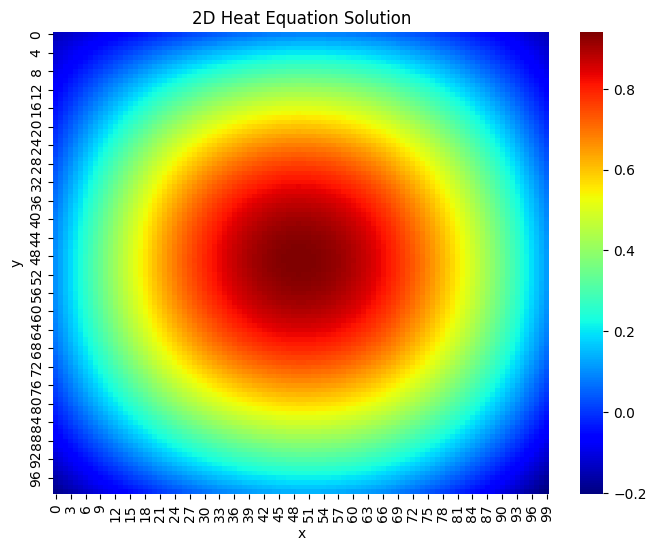

In [11]:
with torch.no_grad():
    x_vals = torch.linspace(0, 1, 100)
    y_vals = torch.linspace(0, 1, 100)
    X, Y = torch.meshgrid(x_vals, y_vals)
    # Spacify the time
    t_vals = torch.ones_like(X) * 0

    input_data = torch.stack([X.flatten(), Y.flatten(), t_vals.flatten()], dim=1)
    solution = model(input_data).reshape(X.shape)

    plt.figure(figsize=(8,6))
    sns.heatmap(solution, cmap="jet")
    plt.title("2D Heat Equation Solution")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()